Cell 1: Install and import libraries

In [1]:
!pip -q install torchsummary

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
from torchsummary import summary

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import random
import time
import copy

Cell 2: Set seed and device

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


Cell 3: Load CIFAR-10 with same split as Problem 1

In [4]:
batch_size = 128

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_full_aug = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

train_full_clean = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=test_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

num_train = len(train_full_aug)
indices = np.arange(num_train)

np.random.seed(SEED)
np.random.shuffle(indices)

train_size = 45000

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_full_aug, train_indices)
val_dataset = Subset(train_full_clean, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

classes = test_dataset.classes

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
print("Classes:", classes)

100%|██████████| 170M/170M [00:02<00:00, 75.6MB/s]


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Cell 4: Define parameter counting function

In [5]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Cell 5: Define the modified AlexNet from Problem 1

In [6]:
class ModifiedAlexNet(nn.Module):
    def __init__(self, dropout_p=0.0):
        super(ModifiedAlexNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [7]:
alexnet_reference = ModifiedAlexNet(dropout_p=0.0).to(device)
alexnet_param_count = count_parameters(alexnet_reference)

print("Modified AlexNet parameter count:", alexnet_param_count)

Modified AlexNet parameter count: 2438922


Cell 6: Define adapted VGGNet models

In [8]:
vgg_cfgs = {
    "VGG11": [
        32, "M",
        64, "M",
        128, 128, "M",
        256, 256, "M",
        256, 256, "M"
    ],

    "VGG13": [
        32, 32, "M",
        64, 64, "M",
        128, 128, "M",
        256, 256, "M",
        256, 256, "M"
    ],

    "VGG16": [
        32, 32, "M",
        64, 64, "M",
        128, 128, 128, "M",
        256, 256, 256, "M",
        256, 256, 256, "M"
    ],

    "VGG19": [
        32, 32, "M",
        64, 64, "M",
        128, 128, 128, 128, "M",
        256, 256, 256, 256, "M",
        256, 256, 256, 256, "M"
    ]
}

In [9]:
class AdaptedVGG(nn.Module):
    def __init__(self, cfg, dropout_p=0.0, batch_norm=False):
        super(AdaptedVGG, self).__init__()

        self.features = self.make_layers(cfg, batch_norm=batch_norm)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        last_channels = self.get_last_channels(cfg)

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(last_channels, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),

            nn.Linear(256, 10)
        )

    def make_layers(self, cfg, batch_norm=False):
        layers = []
        in_channels = 3

        for layer in cfg:
            if layer == "M":
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            else:
                conv2d = nn.Conv2d(
                    in_channels,
                    layer,
                    kernel_size=3,
                    stride=1,
                    padding=1
                )

                if batch_norm:
                    layers.extend([
                        conv2d,
                        nn.BatchNorm2d(layer),
                        nn.ReLU(inplace=True)
                    ])
                else:
                    layers.extend([
                        conv2d,
                        nn.ReLU(inplace=True)
                    ])

                in_channels = layer

        return nn.Sequential(*layers)

    def get_last_channels(self, cfg):
        for layer in reversed(cfg):
            if layer != "M":
                return layer

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

Cell 7: Compare VGG-11, VGG-13, VGG-16, and VGG-19 parameter counts

In [10]:
vgg_param_rows = []

for name, cfg in vgg_cfgs.items():
    model = AdaptedVGG(cfg=cfg, dropout_p=0.0, batch_norm=False).to(device)
    params = count_parameters(model)
    difference = abs(params - alexnet_param_count)

    vgg_param_rows.append({
        "VGG Model": name,
        "Parameters": params,
        "Difference from AlexNet": difference
    })

vgg_param_df = pd.DataFrame(vgg_param_rows)
vgg_param_df = vgg_param_df.sort_values("Difference from AlexNet")

vgg_param_df

,VGG Model,Parameters,Difference from AlexNet
0,VGG11,2571722,132800
1,VGG13,2617898,178976
2,VGG16,3945642,1506720
3,VGG19,5273386,2834464


In [11]:
selected_vgg_name = vgg_param_df.iloc[0]["VGG Model"]
selected_vgg_cfg = vgg_cfgs[selected_vgg_name]

print("Selected VGG model:", selected_vgg_name)
print("Reason: It has the closest parameter count to the modified AlexNet.")

Selected VGG model: VGG11
Reason: It has the closest parameter count to the modified AlexNet.


Cell 8: Show summary of selected VGG model

In [12]:
vgg_baseline_model = AdaptedVGG(
    cfg=selected_vgg_cfg,
    dropout_p=0.0,
    batch_norm=False
).to(device)

summary(vgg_baseline_model, input_size=(3, 32, 32))

print("Selected VGG:", selected_vgg_name)
print("VGG parameter count:", count_parameters(vgg_baseline_model))
print("AlexNet parameter count:", alexnet_param_count)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
              ReLU-5           [-1, 64, 16, 16]               0
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
              ReLU-8            [-1, 128, 8, 8]               0
            Conv2d-9            [-1, 128, 8, 8]         147,584
             ReLU-10            [-1, 128, 8, 8]               0
        MaxPool2d-11            [-1, 128, 4, 4]               0
           Conv2d-12            [-1, 256, 4, 4]         295,168
             ReLU-13            [-1, 256, 4, 4]               0
           Conv2d-14            [-1, 25

Cell 9: Training function with time per epoch

In [13]:
def train_one_model(model, train_loader, val_loader, epochs=30, lr=0.001, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    total_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()

        model.train()

        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        scheduler.step()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100 * correct_train / total_train

        model.eval()

        val_running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = 100 * correct_val / total_val

        epoch_time = time.time() - epoch_start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.2f}% "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_acc:.2f}% "
            f"Time: {epoch_time:.2f}s"
        )

    total_time = time.time() - total_start_time

    print("Training complete.")
    print("Best validation accuracy:", best_val_acc)
    print("Average time per epoch:", np.mean(history["epoch_time"]))
    print("Total training time in minutes:", total_time / 60)

    model.load_state_dict(best_model_wts)

    return model, history, best_val_acc

Cell 10: Test evaluation function

In [14]:
def evaluate_on_test(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * correct / total

    return test_acc, np.array(all_labels), np.array(all_preds)

Cell 11: Plotting functions

In [15]:
def plot_single_history(history, title):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Training Loss")
    plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.savefig(title.replace(" ", "_") + "_loss_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], label="Training Accuracy")
    plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(title + " Accuracy Curves")
    plt.legend()
    plt.grid(True)
    plt.savefig(title.replace(" ", "_") + "_accuracy_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

In [16]:
def compare_histories(histories, labels, title):
    epochs_range = range(1, len(histories[0]["train_loss"]) + 1)

    plt.figure(figsize=(9, 6))
    for history, label in zip(histories, labels):
        plt.plot(epochs_range, history["train_loss"], label=f"{label} Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title(title + " Training Loss Comparison")
    plt.legend()
    plt.grid(True)
    plt.savefig(title.replace(" ", "_") + "_training_loss_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 6))
    for history, label in zip(histories, labels):
        plt.plot(epochs_range, history["val_loss"], label=f"{label} Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title(title + " Validation Loss Comparison")
    plt.legend()
    plt.grid(True)
    plt.savefig(title.replace(" ", "_") + "_validation_loss_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 6))
    for history, label in zip(histories, labels):
        plt.plot(epochs_range, history["val_acc"], label=f"{label} Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy (%)")
    plt.title(title + " Validation Accuracy Comparison")
    plt.legend()
    plt.grid(True)
    plt.savefig(title.replace(" ", "_") + "_validation_accuracy_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

In [17]:
def plot_confusion_matrix(labels, preds, title):
    cm = confusion_matrix(labels, preds)

    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=45,
        values_format="d"
    )

    plt.title(title)
    plt.savefig(title.replace(" ", "_") + ".png", dpi=300, bbox_inches="tight")
    plt.show()

Cell 12: Train adapted VGG baseline

Part A

In [18]:
epochs = 30
learning_rate = 0.001
weight_decay = 0.0

vgg_baseline_model = AdaptedVGG(
    cfg=selected_vgg_cfg,
    dropout_p=0.0,
    batch_norm=False
).to(device)

vgg_baseline_model, vgg_baseline_history, vgg_baseline_best_val_acc = train_one_model(
    vgg_baseline_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/30] Train Loss: 1.9284 Train Acc: 23.01% Val Loss: 1.6984 Val Acc: 33.50% Time: 20.31s
Epoch [2/30] Train Loss: 1.5642 Train Acc: 39.33% Val Loss: 1.4402 Val Acc: 46.14% Time: 18.03s
Epoch [3/30] Train Loss: 1.3583 Train Acc: 49.64% Val Loss: 1.2267 Val Acc: 55.60% Time: 20.31s
Epoch [4/30] Train Loss: 1.1757 Train Acc: 57.63% Val Loss: 1.0175 Val Acc: 63.82% Time: 18.09s
Epoch [5/30] Train Loss: 1.0391 Train Acc: 63.33% Val Loss: 1.0057 Val Acc: 63.48% Time: 18.70s
Epoch [6/30] Train Loss: 0.9414 Train Acc: 66.71% Val Loss: 0.8842 Val Acc: 69.10% Time: 17.52s
Epoch [7/30] Train Loss: 0.8742 Train Acc: 69.57% Val Loss: 0.8472 Val Acc: 70.46% Time: 19.10s
Epoch [8/30] Train Loss: 0.8169 Train Acc: 71.56% Val Loss: 0.8241 Val Acc: 71.62% Time: 17.06s
Epoch [9/30] Train Loss: 0.7698 Train Acc: 73.41% Val Loss: 0.7751 Val Acc: 73.36% Time: 19.77s
Epoch [10/30] Train Loss: 0.7288 Train Acc: 74.75% Val Loss: 0.7712 Val Acc: 74.00% Time: 19.02s
Epoch [11/30] Train Loss: 0.6933 Train 

Cell 13: Plot VGG baseline curves

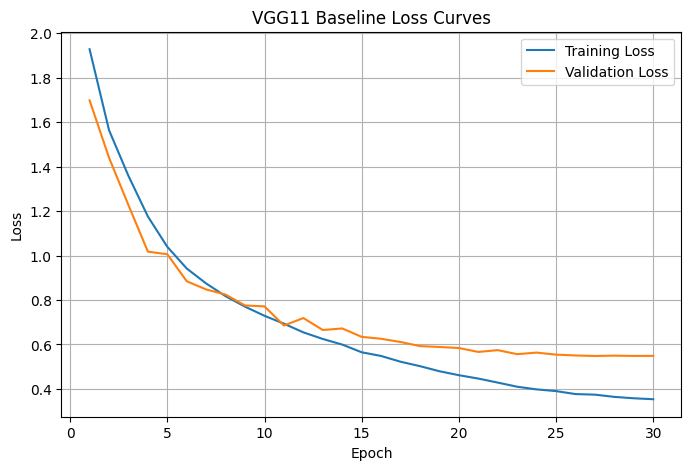

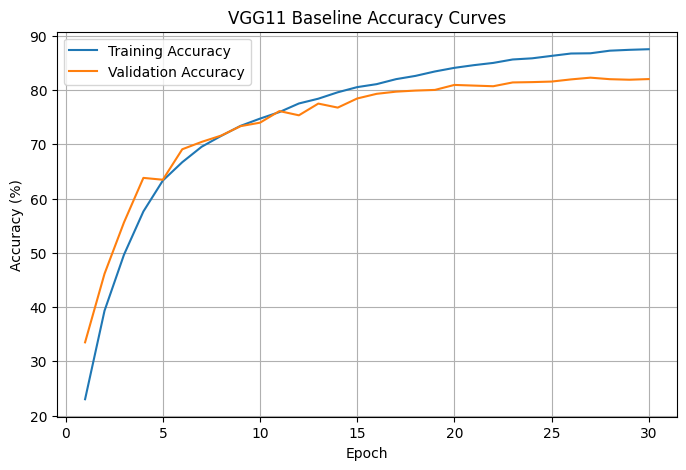

In [19]:
plot_single_history(
    vgg_baseline_history,
    f"{selected_vgg_name} Baseline"
)

Cell 14: Test VGG baseline

In [20]:
vgg_baseline_test_acc, vgg_baseline_labels, vgg_baseline_preds = evaluate_on_test(
    vgg_baseline_model,
    test_loader
)

print(f"{selected_vgg_name} baseline test accuracy:", vgg_baseline_test_acc)

VGG11 baseline test accuracy: 82.06


Cell 15: Confusion matrix for VGG baseline

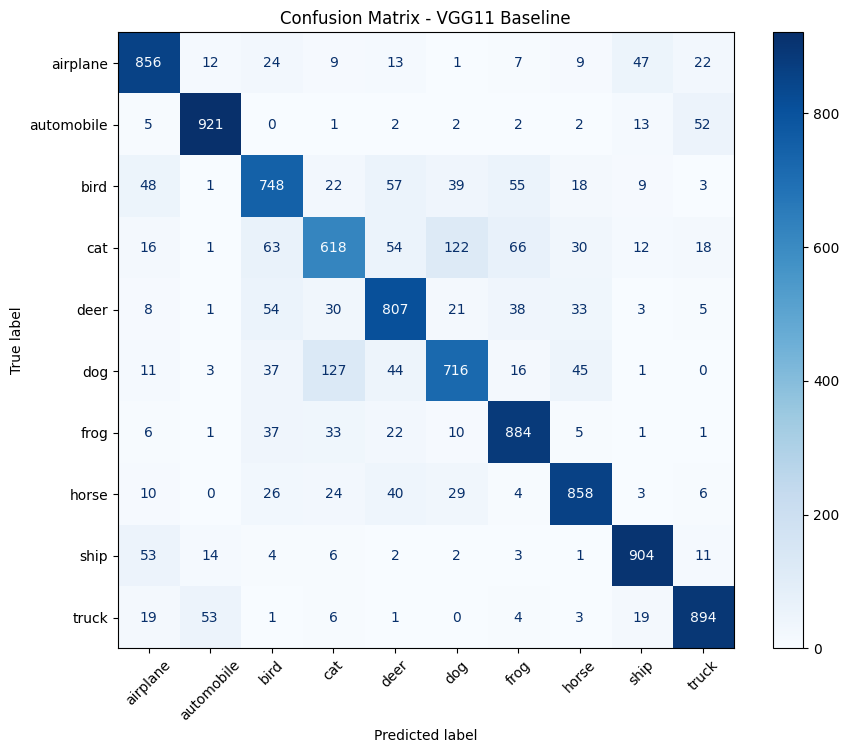

In [21]:
plot_confusion_matrix(
    vgg_baseline_labels,
    vgg_baseline_preds,
    f"Confusion Matrix - {selected_vgg_name} Baseline"
)

Cell 16: Train VGG with dropout p = 0.3

Part B

In [22]:
vgg_dropout03_model = AdaptedVGG(
    cfg=selected_vgg_cfg,
    dropout_p=0.3,
    batch_norm=False
).to(device)

vgg_dropout03_model, vgg_dropout03_history, vgg_dropout03_best_val_acc = train_one_model(
    vgg_dropout03_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/30] Train Loss: 2.0673 Train Acc: 17.09% Val Loss: 1.8625 Val Acc: 23.90% Time: 23.35s
Epoch [2/30] Train Loss: 1.7712 Train Acc: 29.32% Val Loss: 1.5855 Val Acc: 38.56% Time: 18.49s
Epoch [3/30] Train Loss: 1.4779 Train Acc: 43.64% Val Loss: 1.3418 Val Acc: 49.64% Time: 18.92s
Epoch [4/30] Train Loss: 1.2865 Train Acc: 53.01% Val Loss: 1.1489 Val Acc: 58.56% Time: 17.70s
Epoch [5/30] Train Loss: 1.1387 Train Acc: 59.47% Val Loss: 1.0653 Val Acc: 62.24% Time: 18.57s
Epoch [6/30] Train Loss: 1.0284 Train Acc: 63.98% Val Loss: 0.9243 Val Acc: 67.96% Time: 18.40s
Epoch [7/30] Train Loss: 0.9499 Train Acc: 66.74% Val Loss: 0.9513 Val Acc: 66.90% Time: 17.61s
Epoch [8/30] Train Loss: 0.8926 Train Acc: 69.20% Val Loss: 0.9170 Val Acc: 68.32% Time: 18.69s
Epoch [9/30] Train Loss: 0.8352 Train Acc: 71.16% Val Loss: 0.7870 Val Acc: 72.58% Time: 17.96s
Epoch [10/30] Train Loss: 0.8002 Train Acc: 72.48% Val Loss: 0.7946 Val Acc: 73.18% Time: 18.63s
Epoch [11/30] Train Loss: 0.7652 Train 

In [23]:
vgg_dropout03_test_acc, vgg_dropout03_labels, vgg_dropout03_preds = evaluate_on_test(
    vgg_dropout03_model,
    test_loader
)

print(f"{selected_vgg_name} dropout p=0.3 test accuracy:", vgg_dropout03_test_acc)

VGG11 dropout p=0.3 test accuracy: 80.91


Cell 17: Train VGG with dropout p = 0.5

In [24]:
vgg_dropout05_model = AdaptedVGG(
    cfg=selected_vgg_cfg,
    dropout_p=0.5,
    batch_norm=False
).to(device)

vgg_dropout05_model, vgg_dropout05_history, vgg_dropout05_best_val_acc = train_one_model(
    vgg_dropout05_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/30] Train Loss: 1.9853 Train Acc: 18.62% Val Loss: 1.8475 Val Acc: 23.92% Time: 22.60s
Epoch [2/30] Train Loss: 1.7353 Train Acc: 30.87% Val Loss: 1.6065 Val Acc: 37.04% Time: 18.05s
Epoch [3/30] Train Loss: 1.4782 Train Acc: 43.23% Val Loss: 1.3202 Val Acc: 49.32% Time: 17.71s
Epoch [4/30] Train Loss: 1.2947 Train Acc: 53.23% Val Loss: 1.1474 Val Acc: 58.78% Time: 18.72s
Epoch [5/30] Train Loss: 1.1630 Train Acc: 59.32% Val Loss: 1.0586 Val Acc: 62.64% Time: 17.80s
Epoch [6/30] Train Loss: 1.0426 Train Acc: 63.70% Val Loss: 0.9780 Val Acc: 66.16% Time: 18.72s
Epoch [7/30] Train Loss: 0.9714 Train Acc: 66.51% Val Loss: 0.9195 Val Acc: 68.12% Time: 17.87s
Epoch [8/30] Train Loss: 0.9188 Train Acc: 68.65% Val Loss: 0.8878 Val Acc: 69.74% Time: 17.67s
Epoch [9/30] Train Loss: 0.8567 Train Acc: 70.69% Val Loss: 0.8277 Val Acc: 72.56% Time: 18.56s
Epoch [10/30] Train Loss: 0.8133 Train Acc: 72.40% Val Loss: 0.7891 Val Acc: 73.62% Time: 17.60s
Epoch [11/30] Train Loss: 0.7695 Train 

In [25]:
vgg_dropout05_test_acc, vgg_dropout05_labels, vgg_dropout05_preds = evaluate_on_test(
    vgg_dropout05_model,
    test_loader
)

print(f"{selected_vgg_name} dropout p=0.5 test accuracy:", vgg_dropout05_test_acc)

VGG11 dropout p=0.5 test accuracy: 81.54


Cell 18: Compare VGG baseline vs dropout models

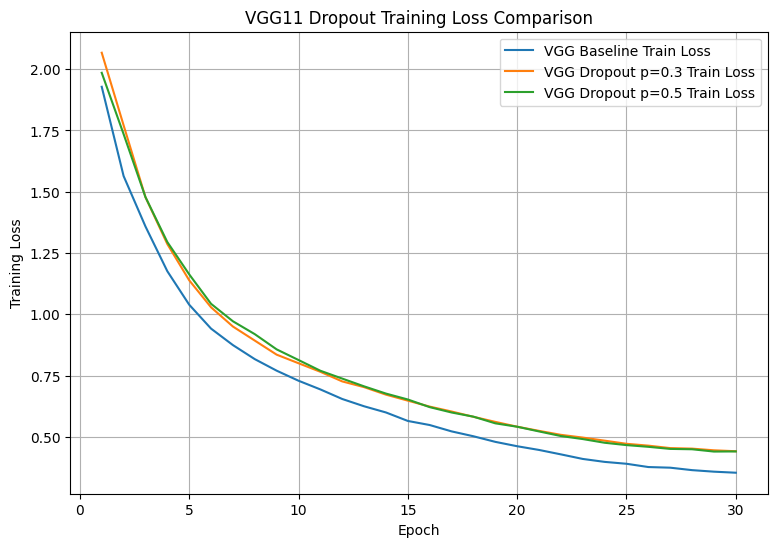

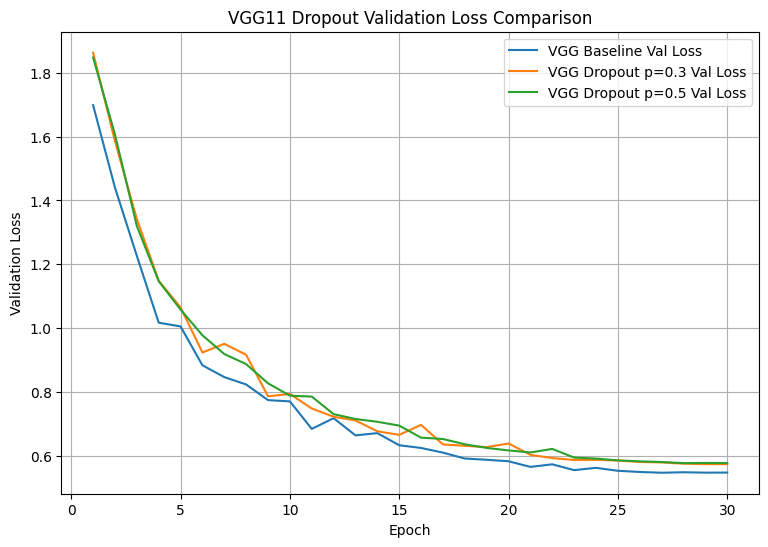

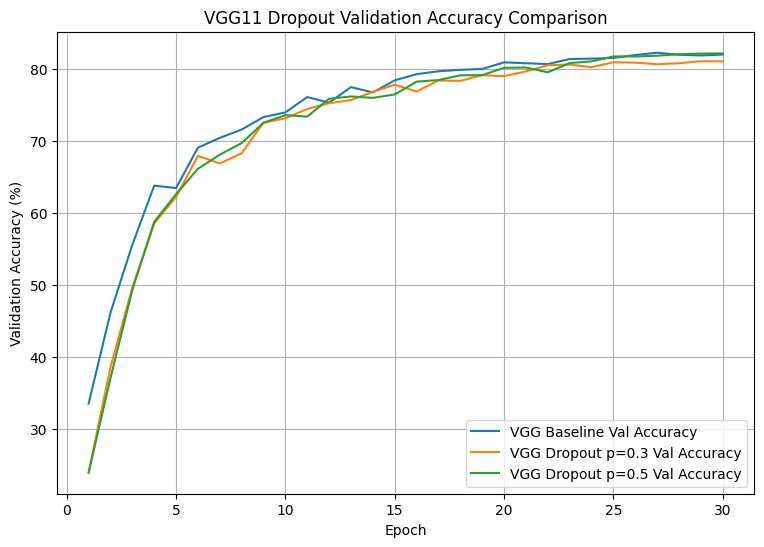

In [26]:
compare_histories(
    histories=[
        vgg_baseline_history,
        vgg_dropout03_history,
        vgg_dropout05_history
    ],
    labels=[
        "VGG Baseline",
        "VGG Dropout p=0.3",
        "VGG Dropout p=0.5"
    ],
    title=f"{selected_vgg_name} Dropout"
)

Cell 19: VGG results table

In [27]:
vgg_results = {
    "Model": [
        f"{selected_vgg_name} Baseline",
        f"{selected_vgg_name} Dropout p=0.3",
        f"{selected_vgg_name} Dropout p=0.5"
    ],
    "Parameters": [
        count_parameters(vgg_baseline_model),
        count_parameters(vgg_dropout03_model),
        count_parameters(vgg_dropout05_model)
    ],
    "Best Validation Accuracy (%)": [
        vgg_baseline_best_val_acc,
        vgg_dropout03_best_val_acc,
        vgg_dropout05_best_val_acc
    ],
    "Test Accuracy (%)": [
        vgg_baseline_test_acc,
        vgg_dropout03_test_acc,
        vgg_dropout05_test_acc
    ],
    "Average Time Per Epoch (s)": [
        np.mean(vgg_baseline_history["epoch_time"]),
        np.mean(vgg_dropout03_history["epoch_time"]),
        np.mean(vgg_dropout05_history["epoch_time"])
    ]
}

vgg_results_df = pd.DataFrame(vgg_results)
vgg_results_df

,Model,Parameters,Best Validation Accuracy (%),Test Accuracy (%),Average Time Per Epoch (s)
0,VGG11 Baseline,2571722,82.30,82.06,18.338162
1,VGG11 Dropout p=0.3,2571722,81.12,80.91,18.601934
2,VGG11 Dropout p=0.5,2571722,82.20,81.54,18.233711


Cell 20: Compare AlexNet vs VGGNet

In [28]:
need_alexnet_training = False

required_alexnet_variables = [
    "baseline_model",
    "baseline_history",
    "baseline_test_acc",
    "dropout03_model",
    "dropout03_history",
    "dropout03_test_acc",
    "dropout05_model",
    "dropout05_history",
    "dropout05_test_acc"
]

for var_name in required_alexnet_variables:
    if var_name not in globals():
        need_alexnet_training = True

print("Need to train AlexNet models again?", need_alexnet_training)

Need to train AlexNet models again? True


In [32]:
if need_alexnet_training:
    print("Training AlexNet baseline...")
    baseline_model = ModifiedAlexNet(dropout_p=0.0).to(device)
    baseline_model, baseline_history, baseline_best_val_acc = train_one_model(
        baseline_model,
        train_loader,
        val_loader,
        epochs=epochs,
        lr=learning_rate,
        weight_decay=weight_decay
    )

    baseline_test_acc, baseline_labels, baseline_preds = evaluate_on_test(
        baseline_model,
        test_loader
    )

    print("Training AlexNet dropout p=0.3...")
    dropout03_model = ModifiedAlexNet(dropout_p=0.3).to(device)
    dropout03_model, dropout03_history, dropout03_best_val_acc = train_one_model(
        dropout03_model,
        train_loader,
        val_loader,
        epochs=epochs,
        lr=learning_rate,
        weight_decay=weight_decay
    )

    dropout03_test_acc, dropout03_labels, dropout03_preds = evaluate_on_test(
        dropout03_model,
        test_loader
    )

    print("Training AlexNet dropout p=0.5...")
    dropout05_model = ModifiedAlexNet(dropout_p=0.5).to(device)
    dropout05_model, dropout05_history, dropout05_best_val_acc = train_one_model(
        dropout05_model,
        train_loader,
        val_loader,
        epochs=epochs,
        lr=learning_rate,
        weight_decay=weight_decay
    )

    dropout05_test_acc, dropout05_labels, dropout05_preds = evaluate_on_test(
        dropout05_model,
        test_loader
    )
else:
    print("Using existing AlexNet results from Problem 1.")

Training AlexNet baseline...
Epoch [1/30] Train Loss: 1.7394 Train Acc: 34.54% Val Loss: 1.4173 Val Acc: 47.38% Time: 20.04s
Epoch [2/30] Train Loss: 1.3074 Train Acc: 51.54% Val Loss: 1.1273 Val Acc: 59.08% Time: 17.61s
Epoch [3/30] Train Loss: 1.0990 Train Acc: 60.23% Val Loss: 1.0231 Val Acc: 64.32% Time: 19.23s
Epoch [4/30] Train Loss: 0.9488 Train Acc: 66.16% Val Loss: 0.9939 Val Acc: 66.28% Time: 18.06s
Epoch [5/30] Train Loss: 0.8584 Train Acc: 69.50% Val Loss: 0.8038 Val Acc: 72.54% Time: 18.86s
Epoch [6/30] Train Loss: 0.7566 Train Acc: 73.44% Val Loss: 0.8505 Val Acc: 70.56% Time: 18.09s
Epoch [7/30] Train Loss: 0.6983 Train Acc: 75.48% Val Loss: 0.7233 Val Acc: 74.42% Time: 17.71s
Epoch [8/30] Train Loss: 0.6383 Train Acc: 77.53% Val Loss: 0.6569 Val Acc: 77.76% Time: 19.25s
Epoch [9/30] Train Loss: 0.5989 Train Acc: 79.27% Val Loss: 0.6915 Val Acc: 76.56% Time: 17.89s
Epoch [10/30] Train Loss: 0.5582 Train Acc: 80.53% Val Loss: 0.6606 Val Acc: 77.58% Time: 18.52s
Epoch [11/

Cell 21: Compare AlexNet baseline vs VGG baseline curves

Problem 1 and Problem 2 Part A compare

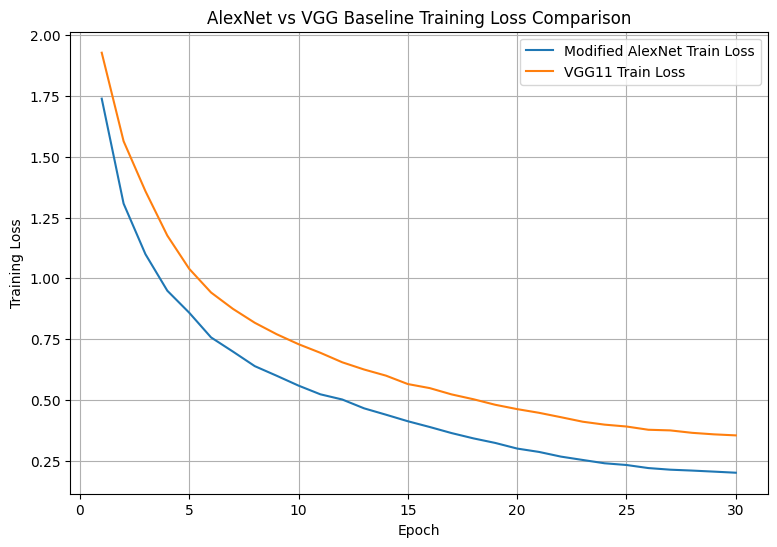

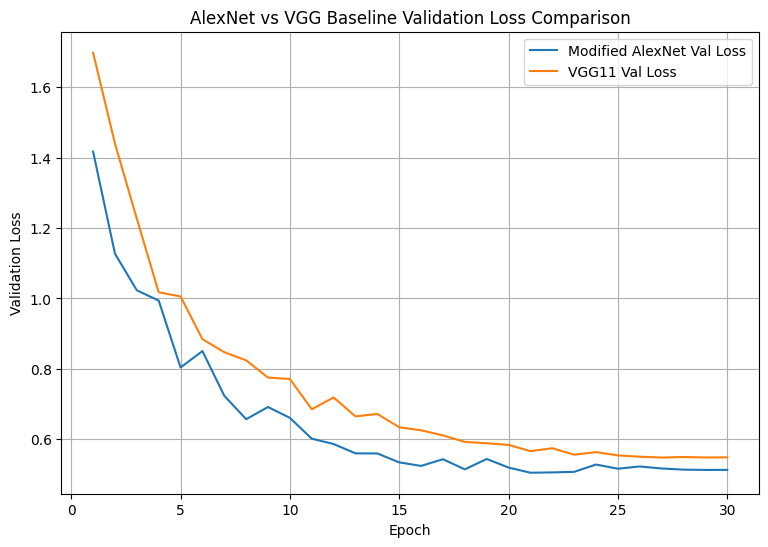

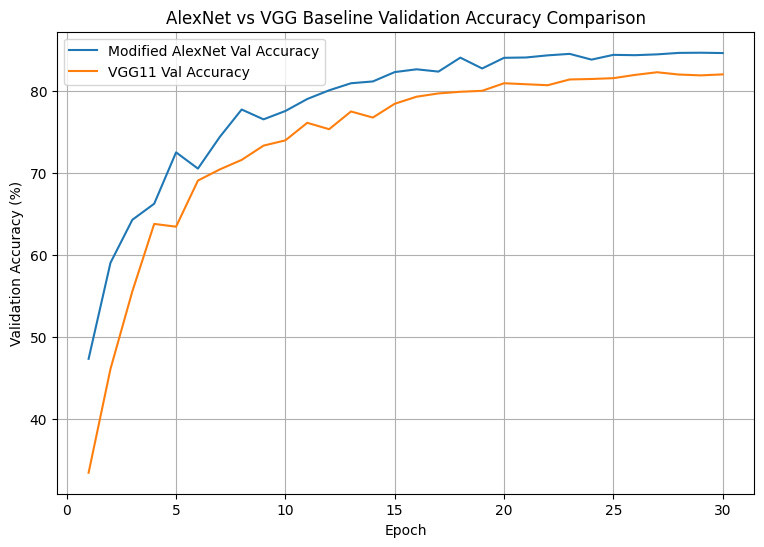

In [33]:
compare_histories(
    histories=[
        baseline_history,
        vgg_baseline_history
    ],
    labels=[
        "Modified AlexNet",
        selected_vgg_name
    ],
    title="AlexNet vs VGG Baseline"
)

Cell 22: Compare all dropout models

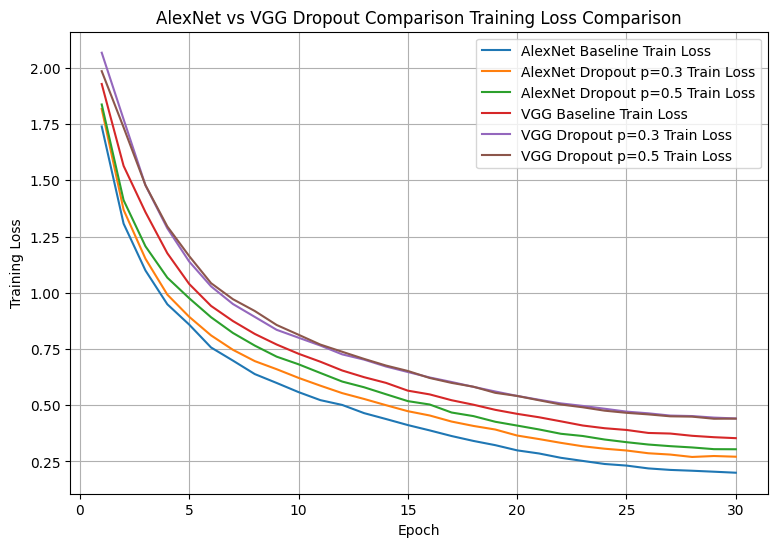

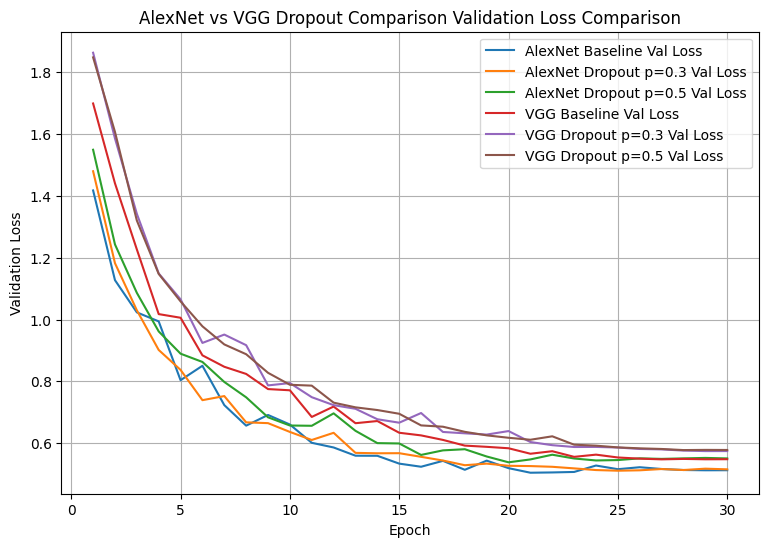

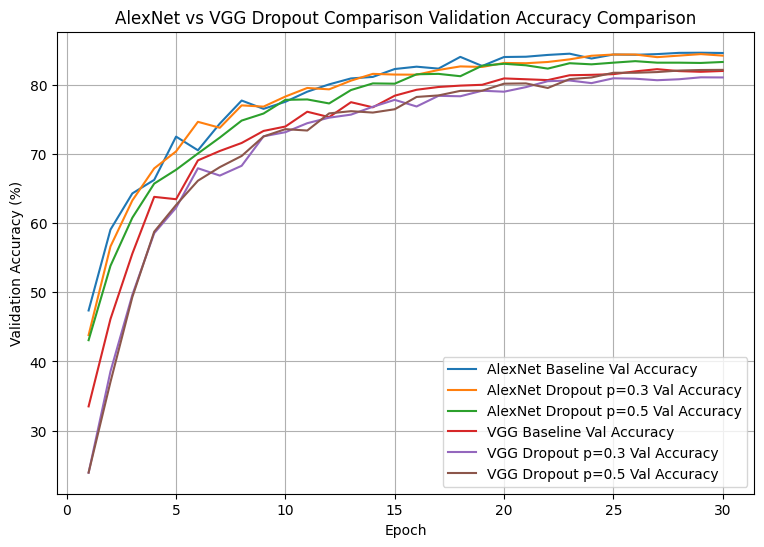

In [40]:
compare_histories(
    histories=[
        baseline_history,
        dropout03_history,
        dropout05_history,
        vgg_baseline_history,
        vgg_dropout03_history,
        vgg_dropout05_history
    ],
    labels=[
        "AlexNet Baseline",
        "AlexNet Dropout p=0.3",
        "AlexNet Dropout p=0.5",
        "VGG Baseline",
        "VGG Dropout p=0.3",
        "VGG Dropout p=0.5"
    ],
    title="AlexNet vs VGG Dropout Comparison"
)

Cell 23: Convergence speed helper

In [34]:
def epoch_to_reach_90_percent_best(history):
    best_acc = max(history["val_acc"])
    target_acc = 0.90 * best_acc

    for i, acc in enumerate(history["val_acc"]):
        if acc >= target_acc:
            return i + 1

    return None

Cell 24: Final comparison table

In [35]:
comparison_results = {
    "Model": [
        "AlexNet Baseline",
        "AlexNet Dropout p=0.3",
        "AlexNet Dropout p=0.5",
        f"{selected_vgg_name} Baseline",
        f"{selected_vgg_name} Dropout p=0.3",
        f"{selected_vgg_name} Dropout p=0.5"
    ],
    "Parameters": [
        count_parameters(baseline_model),
        count_parameters(dropout03_model),
        count_parameters(dropout05_model),
        count_parameters(vgg_baseline_model),
        count_parameters(vgg_dropout03_model),
        count_parameters(vgg_dropout05_model)
    ],
    "Best Validation Accuracy (%)": [
        max(baseline_history["val_acc"]),
        max(dropout03_history["val_acc"]),
        max(dropout05_history["val_acc"]),
        max(vgg_baseline_history["val_acc"]),
        max(vgg_dropout03_history["val_acc"]),
        max(vgg_dropout05_history["val_acc"])
    ],
    "Test Accuracy (%)": [
        baseline_test_acc,
        dropout03_test_acc,
        dropout05_test_acc,
        vgg_baseline_test_acc,
        vgg_dropout03_test_acc,
        vgg_dropout05_test_acc
    ],
    "Average Time Per Epoch (s)": [
        np.mean(baseline_history["epoch_time"]) if "epoch_time" in baseline_history else None,
        np.mean(dropout03_history["epoch_time"]) if "epoch_time" in dropout03_history else None,
        np.mean(dropout05_history["epoch_time"]) if "epoch_time" in dropout05_history else None,
        np.mean(vgg_baseline_history["epoch_time"]),
        np.mean(vgg_dropout03_history["epoch_time"]),
        np.mean(vgg_dropout05_history["epoch_time"])
    ],
    "Epoch to Reach 90% of Best Val Acc": [
        epoch_to_reach_90_percent_best(baseline_history),
        epoch_to_reach_90_percent_best(dropout03_history),
        epoch_to_reach_90_percent_best(dropout05_history),
        epoch_to_reach_90_percent_best(vgg_baseline_history),
        epoch_to_reach_90_percent_best(vgg_dropout03_history),
        epoch_to_reach_90_percent_best(vgg_dropout05_history)
    ]
}

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Model,Parameters,Best Validation Accuracy (%),Test Accuracy (%),Average Time Per Epoch (s),Epoch to Reach 90% of Best Val Acc
0,AlexNet Baseline,2438922,84.68,84.66,18.076287,8
1,AlexNet Dropout p=0.3,2438922,84.48,83.92,18.119017,8
2,AlexNet Dropout p=0.5,2438922,83.46,83.53,18.561949,9
3,VGG11 Baseline,2571722,82.30,82.06,18.338162,11
4,VGG11 Dropout p=0.3,2571722,81.12,80.91,18.601934,10
5,VGG11 Dropout p=0.5,2571722,82.20,81.54,18.233711,12


Bonus Cell 25: VGG with Batch Normalization

In [36]:
vgg_bn_model = AdaptedVGG(
    cfg=selected_vgg_cfg,
    dropout_p=0.0,
    batch_norm=True
).to(device)

vgg_bn_model, vgg_bn_history, vgg_bn_best_val_acc = train_one_model(
    vgg_bn_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/30] Train Loss: 1.5151 Train Acc: 42.17% Val Loss: 1.2639 Val Acc: 55.62% Time: 19.34s
Epoch [2/30] Train Loss: 1.0729 Train Acc: 61.78% Val Loss: 1.0170 Val Acc: 63.98% Time: 18.81s
Epoch [3/30] Train Loss: 0.8896 Train Acc: 68.85% Val Loss: 0.9218 Val Acc: 68.76% Time: 17.51s
Epoch [4/30] Train Loss: 0.7820 Train Acc: 72.96% Val Loss: 0.7661 Val Acc: 74.14% Time: 17.52s
Epoch [5/30] Train Loss: 0.7132 Train Acc: 75.44% Val Loss: 0.6785 Val Acc: 76.60% Time: 18.25s
Epoch [6/30] Train Loss: 0.6421 Train Acc: 78.09% Val Loss: 0.6644 Val Acc: 77.70% Time: 17.77s
Epoch [7/30] Train Loss: 0.5982 Train Acc: 79.53% Val Loss: 0.6234 Val Acc: 78.48% Time: 18.27s
Epoch [8/30] Train Loss: 0.5521 Train Acc: 80.90% Val Loss: 0.5941 Val Acc: 79.20% Time: 17.39s
Epoch [9/30] Train Loss: 0.5162 Train Acc: 82.38% Val Loss: 0.6165 Val Acc: 79.30% Time: 17.44s
Epoch [10/30] Train Loss: 0.4907 Train Acc: 83.08% Val Loss: 0.5267 Val Acc: 82.10% Time: 18.74s
Epoch [11/30] Train Loss: 0.4562 Train 

In [37]:
vgg_bn_test_acc, vgg_bn_labels, vgg_bn_preds = evaluate_on_test(
    vgg_bn_model,
    test_loader
)

print(f"{selected_vgg_name} with BatchNorm test accuracy:", vgg_bn_test_acc)

VGG11 with BatchNorm test accuracy: 87.1


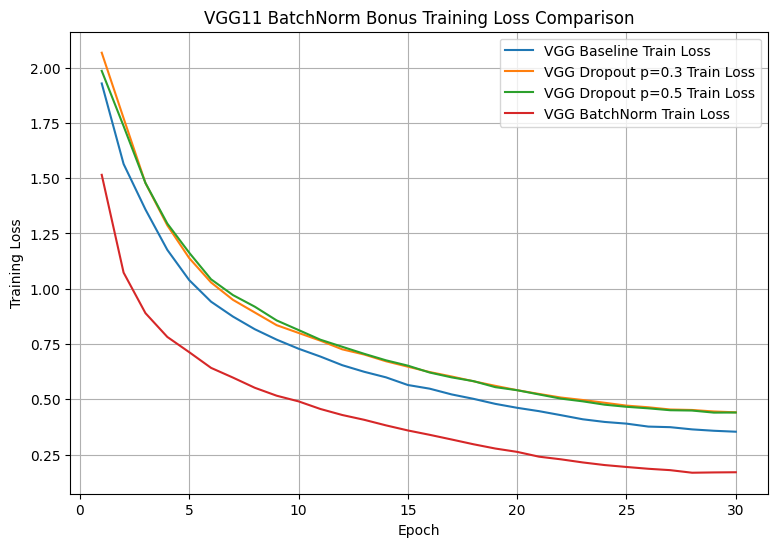

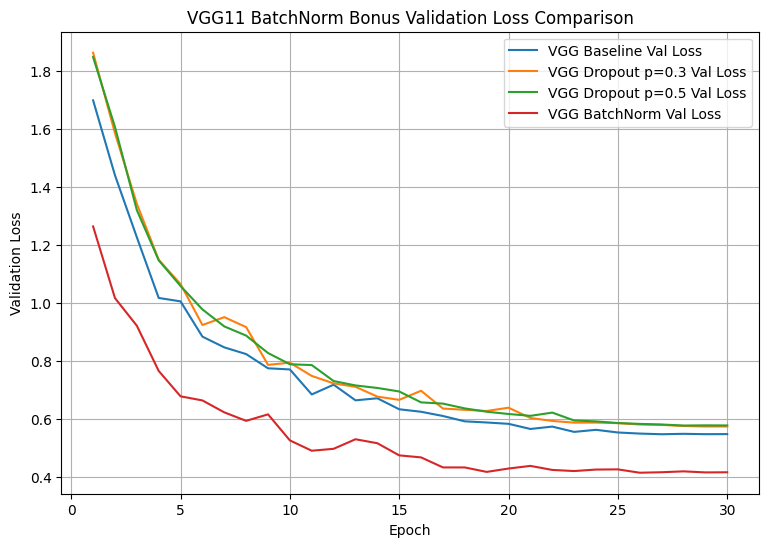

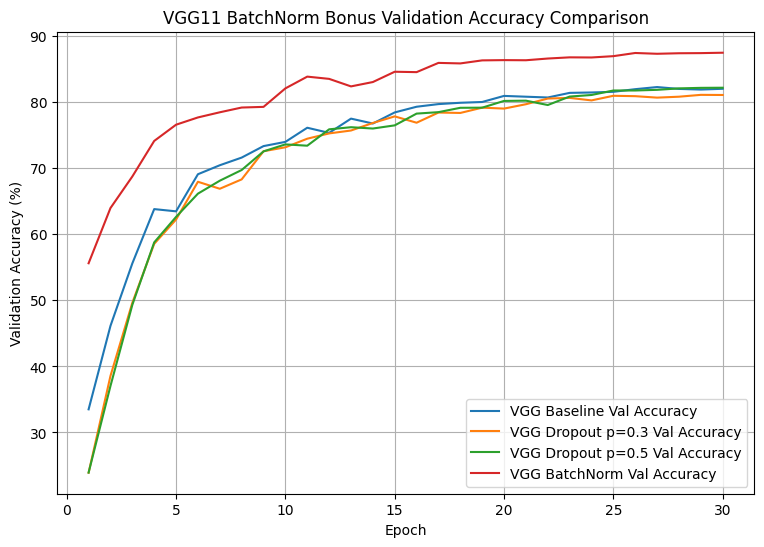

In [38]:
compare_histories(
    histories=[
        vgg_baseline_history,
        vgg_dropout03_history,
        vgg_dropout05_history,
        vgg_bn_history
    ],
    labels=[
        "VGG Baseline",
        "VGG Dropout p=0.3",
        "VGG Dropout p=0.5",
        "VGG BatchNorm"
    ],
    title=f"{selected_vgg_name} BatchNorm Bonus"
)

In [39]:
bonus_results = {
    "Model": [
        f"{selected_vgg_name} Baseline",
        f"{selected_vgg_name} Dropout p=0.3",
        f"{selected_vgg_name} Dropout p=0.5",
        f"{selected_vgg_name} BatchNorm"
    ],
    "Parameters": [
        count_parameters(vgg_baseline_model),
        count_parameters(vgg_dropout03_model),
        count_parameters(vgg_dropout05_model),
        count_parameters(vgg_bn_model)
    ],
    "Best Validation Accuracy (%)": [
        max(vgg_baseline_history["val_acc"]),
        max(vgg_dropout03_history["val_acc"]),
        max(vgg_dropout05_history["val_acc"]),
        max(vgg_bn_history["val_acc"])
    ],
    "Test Accuracy (%)": [
        vgg_baseline_test_acc,
        vgg_dropout03_test_acc,
        vgg_dropout05_test_acc,
        vgg_bn_test_acc
    ],
    "Average Time Per Epoch (s)": [
        np.mean(vgg_baseline_history["epoch_time"]),
        np.mean(vgg_dropout03_history["epoch_time"]),
        np.mean(vgg_dropout05_history["epoch_time"]),
        np.mean(vgg_bn_history["epoch_time"])
    ]
}

bonus_results_df = pd.DataFrame(bonus_results)
bonus_results_df

,Model,Parameters,Best Validation Accuracy (%),Test Accuracy (%),Average Time Per Epoch (s)
0,VGG11 Baseline,2571722,82.30,82.06,18.338162
1,VGG11 Dropout p=0.3,2571722,81.12,80.91,18.601934
2,VGG11 Dropout p=0.5,2571722,82.20,81.54,18.233711
3,VGG11 BatchNorm,2574474,87.50,87.10,18.123901


End of Problem 2